# Convolutional Neural Network (CNN)

## 1. CNN là gì và vì sao cần nó?

CNN là một loại mạng nơ-ron giúp máy tính "nhìn" và hiểu ảnh, theo cách na ná cách con người nhận diện vật thể trong đời thực. Thay vì xem toàn bộ ảnh một lúc như mạng feedforward (ANN), CNN chia ảnh ra từng vùng nhỏ, tìm các đặc trưng cục bộ như đường thẳng, góc, vòng tròn, rồi ghép lại để đưa ra dự đoán.

### Một câu hỏi kinh điển: vì sao không dùng ANN cho ảnh?

Một ảnh 28×28 grayscale có 784 pixel. Nếu cho vào MLP (như bài MNIST trước), tầng đầu cần $784 \times 128 = 100.352$ tham số. Với ảnh màu 224×224×3, con số là $\sim 19$ triệu chỉ riêng tầng đầu. Hơn nữa, MLP coi mỗi pixel là một đặc trưng độc lập — nó *quên mất* rằng pixel cạnh nhau có quan hệ với nhau (cùng tạo nên một cái mắt, một cái mũi).

CNN giải quyết hai vấn đề này bằng:
1. **Chia sẻ trọng số** (weight sharing): cùng một filter dùng cho cả ảnh → ít tham số đi rất nhiều.
2. **Kết nối cục bộ** (local connectivity): mỗi neuron chỉ nhìn một vùng nhỏ → giữ được tính chất không gian của ảnh.

### Trực giác bằng ví dụ
Khi nhìn một con mèo, ta không xem hết cả ảnh ngay lập tức. Ta nhận ra tai mèo (hình tam giác), mắt mèo (hình tròn), ria mèo (đường thẳng), rồi não bộ mới kết luận "đây là mèo". CNN cũng làm vậy: dùng các "kính lúp" nhỏ (filter) quét qua ảnh, tìm từng đặc trưng nhỏ, càng lên các tầng sâu càng học được đặc trưng phức tạp.

## 2. Các thành phần chính của CNN

### 2.1. Tầng tích chập (Convolution Layer)

Đây là "đôi mắt" của CNN. Nó dùng một bộ lọc (filter / kernel) trượt qua ảnh, tại mỗi vị trí tính tích chập rồi sinh ra một con số trong feature map.

#### Công thức tích chập

$$
S(i, j) = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I(i+m,\ j+n) \cdot K(m, n)
$$

Trong đó:
- $I$: ảnh đầu vào.
- $K$: filter kích thước $F \times F$.
- $S(i, j)$: giá trị tại vị trí $(i, j)$ trong feature map.

Đọc bằng lời: lấy vùng $F \times F$ của ảnh tại vị trí $(i, j)$, nhân từng phần tử với phần tử tương ứng của filter, rồi cộng tất cả lại.

*Lưu ý kỹ thuật:* trong toán học, tích chập "thật" có một bước lật filter; tích chập trong deep learning thực ra là **cross-correlation** (không lật). Nhưng vì filter được học từ dữ liệu nên việc lật hay không không quan trọng — kết quả huấn luyện như nhau.

### 2.2. Minh hoạ đầy đủ với số "7"

Hãy khám phá tầng tích chập qua một ví dụ cụ thể. Ta dùng filter phát hiện đường ngang để tìm nét trên cùng của số "7".

**Ảnh đầu vào (6×6):**
$$ I = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

Hàng trên cùng toàn 1 = nét ngang, các hàng dưới có một số 1 chéo từ phải sang trái = thân số 7.

**Filter phát hiện đường ngang (3×3):**
$$ K = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix} $$

Filter này phản hồi mạnh khi vùng dưới của patch tối, vùng trên sáng — đặc trưng của một đường ngang nét đậm trên nền trắng phía dưới.

**Kích thước feature map:** với stride 1, không padding:
$$\text{output} = \Big\lfloor\frac{6-3}{1}\Big\rfloor + 1 = 4$$
→ feature map 4×4.

#### Tính từng vị trí

Đối với mỗi vị trí $(i, j)$ của output, ta lấy patch $I[i:i+3,\ j:j+3]$, nhân từng phần tử với $K$, rồi cộng dồn.

**$(0, 0)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1+1+1 = 3$

**$(0, 1)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 2)$:** patch = $\begin{bmatrix}1&1&1\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 3)$:** patch = $\begin{bmatrix}1&1&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(1, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(1, 1)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$  *(không phải +1, đây là chỗ cần chú ý kẻo nhầm dấu)*

**$(1, 2)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(1, 3)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(2, 1)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(2, 2)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 3)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 0)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(3, 1)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 2)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 3)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 0$

**Feature map hoàn chỉnh:**
$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Nhìn vào feature map: dòng đầu có giá trị lớn (2-3) — filter "kêu to" nhất ở vùng có nét ngang trên cùng. Đó chính là điều ta muốn: filter đã phát hiện đúng vị trí đường ngang của số 7.

![Hình minh hoạ phép tích chập trên ảnh số 7](attachment:conv7.png)


#### Padding và Stride

- **Padding ($P$)**: thêm số 0 quanh ảnh. Nếu $P=0$ (như trên), feature map nhỏ hơn ảnh gốc. Padding `'same'` thêm vừa đủ để output cùng kích thước input.
- **Stride ($S$)**: bước trượt của filter. $S=1$ trượt từng pixel, $S=2$ nhảy cách 2 pixel — output nhỏ đi một nửa.

Công thức kích thước đầu ra (với phép chia làm tròn xuống):
$$
\text{Output Height} = \Big\lfloor\frac{H - F + 2P}{S}\Big\rfloor + 1
$$
$$
\text{Output Width} = \Big\lfloor\frac{W - F + 2P}{S}\Big\rfloor + 1
$$

Kiểm tra với ví dụ: $H = W = 6$, $F=3$, $P=0$, $S=1$ → $(6-3)/1 + 1 = 4$, đúng với feature map 4×4.

### 2.3. Hàm kích hoạt ReLU

Sau khi có feature map, ta áp dụng ReLU để loại bỏ các giá trị âm. Ý tưởng: giá trị âm thường nghĩa là vùng đó *không* có đặc trưng filter đang tìm — bỏ đi cho đỡ ồn.

$$ \text{ReLU}(x) = \max(0, x) $$

Áp dụng vào feature map ở trên:

$$ \text{ReLU}(S) = \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Các -1 đã bị nén về 0. Vì sao chọn ReLU thay vì sigmoid hay tanh? Vì sigmoid và tanh có gradient bão hoà ở vùng giá trị lớn — gradient gần 0 → mạng học rất chậm khi đi sâu. ReLU tránh được vấn đề này (gradient là 1 với x > 0).

### 2.4. Tầng Pooling

Pooling "tóm tắt" feature map, giảm kích thước nhưng giữ thông tin chính. Loại phổ biến nhất: **Max Pooling** — trong mỗi vùng nhỏ chỉ giữ giá trị lớn nhất.

Áp dụng max pooling 2×2 stride 2 lên feature map sau ReLU:

- Vùng góc trên trái $\{3, 2, 0, 0\}$ → max = 3
- Vùng góc trên phải $\{2, 2, 0, 1\}$ → max = 2
- Vùng góc dưới trái $\{0, 0, 0, 1\}$ → max = 1
- Vùng góc dưới phải $\{1, 1, 1, 0\}$ → max = 1

$$ P = \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

Ngoài giảm kích thước (giúp tính nhanh hơn), pooling còn cho mạng tính **bất biến với dịch chuyển nhỏ**: nếu ảnh dịch sang phải vài pixel, max pooling vẫn ra cùng một giá trị.

![Trước và sau khi áp dụng ReLU](attachment:relu.png)


![Trước và sau khi áp dụng MaxPooling](attachment:pool.png)


### 2.5. Tầng Fully Connected

Sau vài tầng conv + pool, ta "duỗi" feature map cuối thành vector và đưa qua một tầng Linear thông thường — đây là bước "ghép các đặc trưng lại để ra quyết định".

$$ y = Wx + b $$

**Ví dụ:** lấy feature map sau pooling = $\begin{bmatrix}3 & 2 \\ 1 & 1\end{bmatrix}$, duỗi thành $x = [3, 2, 1, 1]$.

Phân loại 2 lớp: "là 7" / "không phải 7". Cho:
$$ W = \begin{bmatrix} 0.5 & 0.2 & 0.3 & 0.4 \\ -0.1 & 0.3 & 0.2 & -0.5 \end{bmatrix},\quad b = \begin{bmatrix}0.1\\0.2\end{bmatrix} $$

Tính từng output:
- $y_0 = (0.5 \cdot 3 + 0.2 \cdot 2 + 0.3 \cdot 1 + 0.4 \cdot 1) + 0.1 = (1.5 + 0.4 + 0.3 + 0.4) + 0.1 = 2.6 + 0.1 = 2.7$
- $y_1 = (-0.1 \cdot 3 + 0.3 \cdot 2 + 0.2 \cdot 1 + (-0.5) \cdot 1) + 0.2 = (-0.3 + 0.6 + 0.2 - 0.5) + 0.2 = 0.0 + 0.2 = 0.2$

Sau softmax:
$$P(\text{là 7}) = \frac{e^{2.7}}{e^{2.7} + e^{0.2}} \approx 0.924$$
$$P(\text{không phải 7}) = \frac{e^{0.2}}{e^{2.7} + e^{0.2}} \approx 0.076$$

Mạng kết luận: 92.4% xác suất là số 7.

## 3. Tóm tắt pipeline CNN

1. **Conv** → tìm đặc trưng cục bộ → feature map.
2. **ReLU** → giữ tín hiệu dương, bỏ tín hiệu âm.
3. **Pool** → tóm tắt + giảm kích thước.
4. (Lặp lại 1-3 nhiều lần để học đặc trưng từ thấp đến cao.)
5. **Flatten + FC** → ra quyết định cuối cùng.
6. **Softmax + CrossEntropy** (lúc train) → tính loss.

Càng đi sâu vào mạng, các filter càng học được đặc trưng phức tạp hơn: tầng đầu phát hiện cạnh, tầng giữa phát hiện hình tròn / góc, tầng cuối phát hiện cả "con mèo" hay "chữ số 7".

![Tầng Fully Connected](attachment:fc.png)


![Pipeline CNN tổng hợp](attachment:pipe.png)


# BÀI THỰC HÀNH: PHÂN LOẠI MNIST BẰNG CNN

Ở bài MNIST với ANN, ta đạt khoảng 97-98% test accuracy. Bây giờ ta sẽ thấy CNN có thể vượt 99% với *ít tham số hơn*.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [21]:
# Chuẩn hoá MNIST với mean/std của tập train.

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)), # Data Augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')


Số ảnh train: 60000,  test: 10000


## Kiến trúc model

```
Input  (1, 28, 28)
  │
Conv1 (1→16, k=3) → 16, 26, 26      vì (28-3)/1 + 1 = 26
  │ ReLU + MaxPool 2×2
  → (16, 13, 13)                     26 / 2 = 13
  │
Conv2 (16→32, k=3) → 32, 11, 11      vì (13-3)/1 + 1 = 11
  │ ReLU + MaxPool 2×2
  → (32, 5, 5)                       floor(11/2) = 5
  │ Flatten → 800
  │
FC (800 → 10) → logits
```

Lưu ý số 5×5 ở cuối: vì 11 lẻ nên max pool 2×2 cho ra 5 (làm tròn xuống). Sinh viên hay mắc lỗi tính nhầm chỗ này, dẫn đến `nn.Linear` sai chiều và chương trình lỗi shape mismatch.

In [22]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)           # (5,5) -> (5,5) (with padding)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25) # Add dropout layer
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = self.pool(torch.relu(self.conv3(x)))   # → (64,  2,  2)
        x = self.dropout(x)                        # Apply dropout
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## Huấn luyện

Tracking đúng cách: cộng dồn loss theo *số mẫu*, không theo *số batch* (vì batch cuối có thể nhỏ hơn).

In [24]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/10  train_loss=0.4554  train_acc=85.11%  test_loss=0.0580  test_acc=98.29%
Epoch 2/10  train_loss=0.1467  train_acc=95.48%  test_loss=0.0401  test_acc=98.81%
Epoch 3/10  train_loss=0.1190  train_acc=96.37%  test_loss=0.0319  test_acc=99.00%
Epoch 4/10  train_loss=0.1045  train_acc=96.79%  test_loss=0.0290  test_acc=99.02%
Epoch 5/10  train_loss=0.0900  train_acc=97.20%  test_loss=0.0273  test_acc=99.12%
Epoch 6/10  train_loss=0.0832  train_acc=97.50%  test_loss=0.0265  test_acc=99.18%
Epoch 7/10  train_loss=0.0808  train_acc=97.54%  test_loss=0.0278  test_acc=99.16%
Epoch 8/10  train_loss=0.0763  train_acc=97.67%  test_loss=0.0277  test_acc=99.03%
Epoch 9/10  train_loss=0.0714  train_acc=97.84%  test_loss=0.0266  test_acc=99.27%
Epoch 10/10  train_loss=0.0671  train_acc=97.92%  test_loss=0.0221  test_acc=99.31%


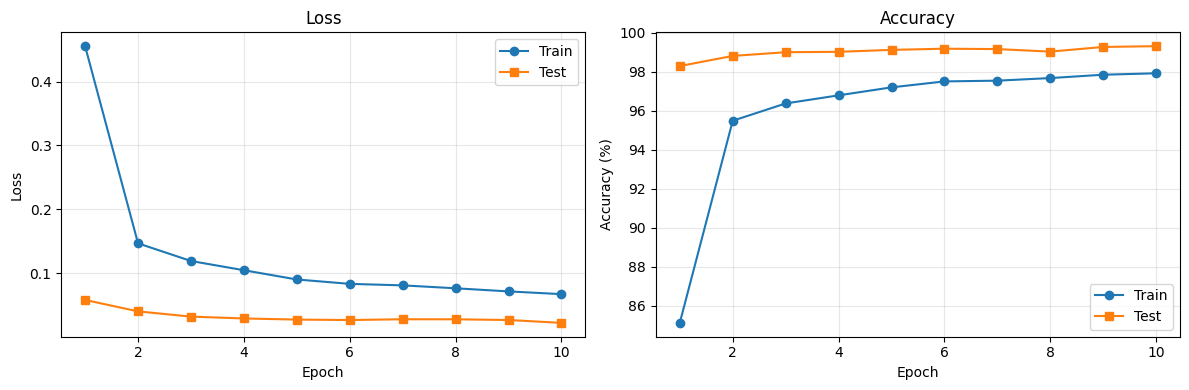

In [25]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

## Đánh giá trên test set

In [26]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 99.31%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


## Trực quan: model dự đoán

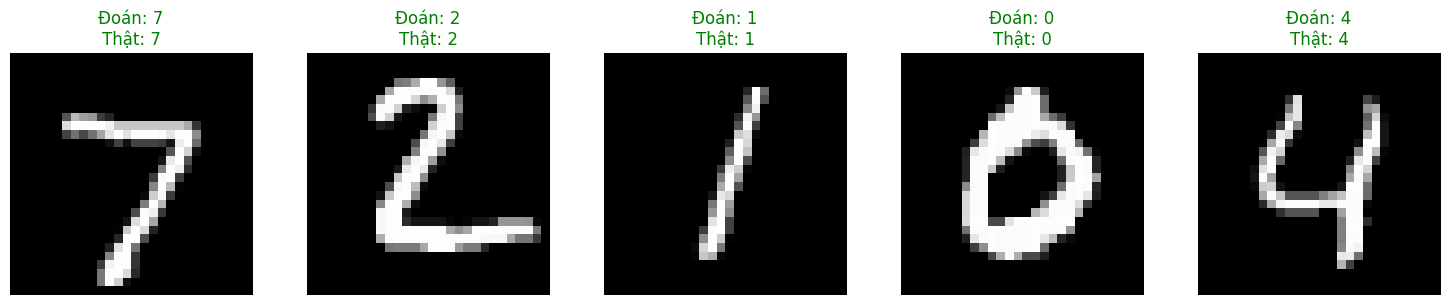

In [27]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## Trực quan: feature maps

Nhìn xem các filter của tầng conv1 đã học được điều gì.

### Quan sát và So sánh Feature Maps:

*   **Feature maps của Conv1:** Các feature map ở tầng này thường hiển thị các đặc trưng cấp thấp (low-level features) như cạnh (edges) với các hướng khác nhau (ngang, dọc, chéo), các đường nét (lines), hoặc các góc (corners). Chúng vẫn còn khá giống với hình ảnh gốc nhưng làm nổi bật một số chi tiết cụ thể.

*   **Feature maps của Conv2:** Ở tầng sâu hơn, các feature map bắt đầu trở nên trừu tượng hơn. Chúng tổng hợp các đặc trưng cấp thấp từ Conv1 để tạo ra các đặc trưng phức tạp hơn (mid-level features) như các hình dạng cơ bản (ví dụ: vòng cung, hình tròn, các phần của chữ số). Các hình ảnh trong feature map không còn dễ dàng nhận ra là một phần của chữ số gốc nữa mà là sự kết hợp của nhiều cạnh và đường nét.

*   **Feature maps của Conv3:** Với việc thêm tầng tích chập thứ ba, các feature map ở đây càng trở nên trừu tượng hơn nữa (high-level features). Chúng kết hợp các đặc trưng từ Conv2 để nhận diện các mẫu phức tạp hơn, gần với các khái niệm của vật thể hơn. Việc giải thích trực quan trở nên khó khăn hơn đối với mắt người, vì các filter đang tìm kiếm các đặc trưng rất cụ thể mà mô hình học được để phân biệt các lớp.

**Kết luận:** Càng đi sâu vào mạng, các feature map càng chuyển từ việc nhận diện các đặc trưng đơn giản, cục bộ (như cạnh) sang nhận diện các đặc trưng phức tạp, trừu tượng (như các phần của chữ số hoặc thậm chí toàn bộ chữ số).

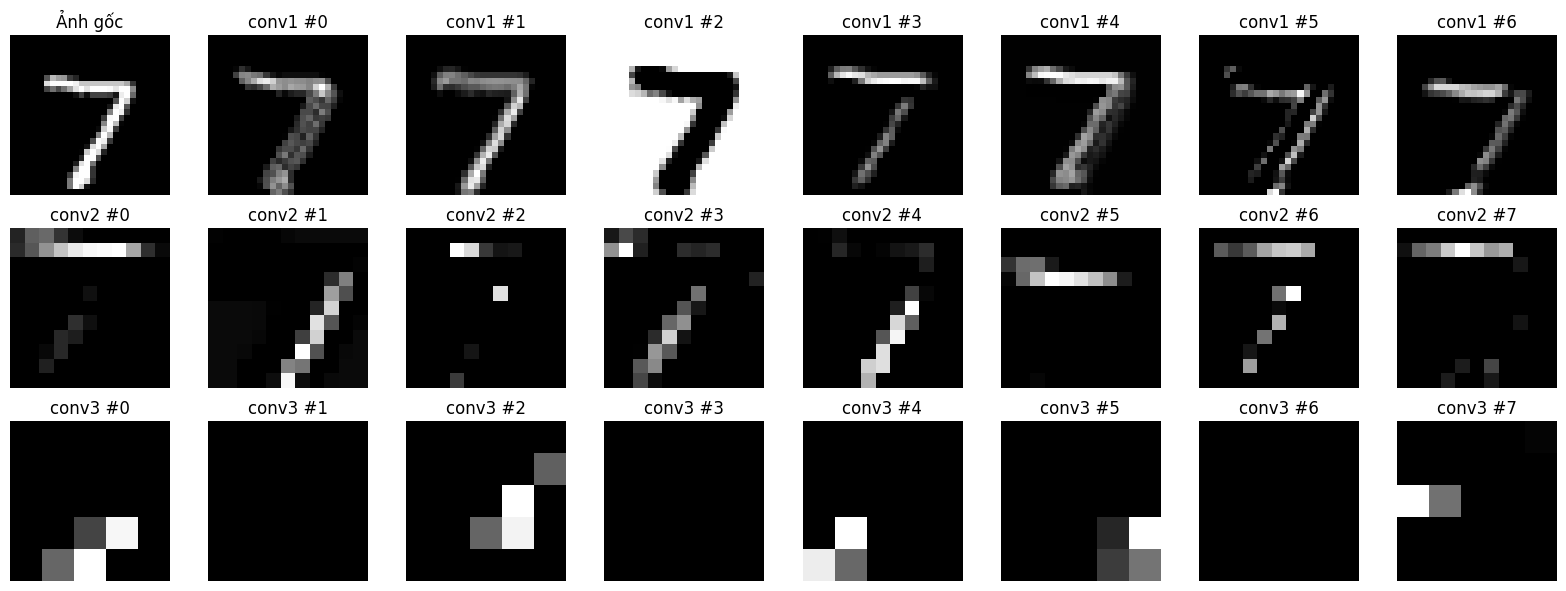

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình).
         filter conv3 nhận các đặc trưng còn trừu tượng hơn nữa, tổng hợp từ conv2.


In [28]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1_pooled = model.pool(h1)
    h2 = torch.relu(model.conv2(h1_pooled))
    h2_pooled = model.pool(h2)
    fmap3 = torch.relu(model.conv3(h2_pooled))

fig, axes = plt.subplots(3, 8, figsize=(16, 6)) # Increased rows to 3 for conv3

# Original image
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')

# Conv1 feature maps
for i in range(7): # Display 7 conv1 feature maps as before
    axes[0, i+1].imshow(h1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')

# Conv2 feature maps
for i in range(8): # Display 8 conv2 feature maps
    axes[1, i].imshow(h2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')

# Conv3 feature maps
for i in range(8): # Display 8 conv3 feature maps
    axes[2, i].imshow(fmap3[0, i].cpu(), cmap='gray')
    axes[2, i].set_title(f'conv3 #{i}'); axes[2, i].axis('off')

plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình).')
print('         filter conv3 nhận các đặc trưng còn trừu tượng hơn nữa, tổng hợp từ conv2.')

# BÀI TẬP VỀ NHÀ

Nộp file `.ipynb` lên GitHub. Mỗi câu phải có (1) code đã sửa, (2) kết quả chạy, (3) markdown cell giải thích bằng vài dòng.

## Câu 1: Train lâu hơn
Tăng số epoch từ 5 lên 10. Báo cáo:
- Test accuracy sau epoch 10 so với epoch 5 — chênh nhau bao nhiêu?
- Khoảng cách `train_acc - test_acc` mở rộng dần không? Đó là dấu hiệu gì?

*Gợi ý:* sửa `num_epochs = 10`, không cần đổi gì khác. Nếu thấy gap mở rộng → overfitting bắt đầu xuất hiện.

## Câu 2: Thêm tầng tích chập thứ ba
Thêm `conv3` để mạng sâu hơn.
- Trong `__init__`: thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)`. Dùng `padding=1` để giữ kích thước không bị giảm thêm.
- Trong `forward`: thêm `x = self.pool(torch.relu(self.conv3(x)))` sau conv2.
- Tính lại kích thước feature map: sau conv2 + pool ta có `(32, 5, 5)`. Sau conv3 padding=1: `(64, 5, 5)`. Sau pool: `(64, 2, 2)` (vì floor(5/2)=2).
- Đổi `fc1 = nn.Linear(64 * 2 * 2, 10)`.

*Gợi ý:* Nếu code lỗi shape mismatch, in `print(x.shape)` ngay trước `view` để tìm chiều thật.

## Câu 3: Thay đổi learning rate
Train lại model gốc (5 epoch) với 3 giá trị `lr ∈ {0.001, 0.01, 0.1}`. Vẽ 3 đường loss trên cùng đồ thị.
- Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
- Trong báo cáo: giải thích vì sao `lr` ảnh hưởng đến hành vi học.

## Câu 4: Vẽ thêm feature maps từ conv2
Sửa hàm hiển thị feature maps để trực quan thêm 2 feature map từ tầng conv2 (đã có sẵn ở cell `cnn-cell-09` ở trên — em chỉ cần đọc kỹ và viết lại theo cách của mình).

*Gợi ý cách lấy feature map của conv2 từ ngoài class:*
```python
with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))   # đây là feature map của conv2
```
Sau đó vẽ một số kênh trong `h2` bằng `imshow`.

Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?

## Câu 5: Thêm Dropout và Data Augmentation
- Thêm `nn.Dropout(p=0.25)` sau pool cuối cùng và trước `fc1`.
- Thêm augmentation vào `transform` lúc train: `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))`. Lưu ý: chỉ áp dụng cho train, KHÔNG áp dụng cho test.
- Train 10 epoch, so sánh test acc với mô hình không có dropout/augmentation.

Báo cáo: dropout và augmentation giúp giảm overfitting như thế nào?

## Deadline
23h59 ngày 11/03/2026.

## Câu 3: Thay đổi learning rate

Tiến hành train lại mô hình gốc (5 epoch) với 3 giá trị learning rate khác nhau: 0.001, 0.01, và 0.1. Sau đó, tôi sẽ vẽ 3 đường loss trên cùng một đồ thị để so sánh hiệu quả.

In [29]:
# Define different learning rates to test
lr_values = [0.001, 0.01, 0.1]
all_loss_histories = {}
all_acc_histories = {}

# Retrain for each learning rate
for lr in lr_values:
    print(f"\nTraining with learning rate: {lr}")

    # Re-initialize the model for each LR test to ensure a clean start
    model = MNIST_CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    num_epochs_lr = 5 # As requested for 'model gốc (5 epoch)'
    loss_history_lr, acc_history_lr = [], []
    test_loss_history_lr, test_acc_history_lr = [], []

    for epoch in range(num_epochs_lr):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total
        test_loss, test_acc = evaluate(model, test_loader)
        loss_history_lr.append(train_loss); acc_history_lr.append(train_acc)
        test_loss_history_lr.append(test_loss); test_acc_history_lr.append(test_acc)

        print(f'Epoch {epoch+1}/{num_epochs_lr}  '
              f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
              f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

    all_loss_histories[lr] = loss_history_lr
    all_acc_histories[lr] = acc_history_lr


Training with learning rate: 0.001
Epoch 1/5  train_loss=1.2088  train_acc=60.79%  test_loss=0.2114  test_acc=94.41%
Epoch 2/5  train_loss=0.3664  train_acc=88.88%  test_loss=0.1239  test_acc=96.33%
Epoch 3/5  train_loss=0.2683  train_acc=91.77%  test_loss=0.0893  test_acc=97.24%
Epoch 4/5  train_loss=0.2195  train_acc=93.28%  test_loss=0.0811  test_acc=97.58%
Epoch 5/5  train_loss=0.1883  train_acc=94.25%  test_loss=0.0645  test_acc=98.10%

Training with learning rate: 0.01
Epoch 1/5  train_loss=0.4608  train_acc=84.88%  test_loss=0.0750  test_acc=97.77%
Epoch 2/5  train_loss=0.1457  train_acc=95.46%  test_loss=0.0433  test_acc=98.57%
Epoch 3/5  train_loss=0.1126  train_acc=96.56%  test_loss=0.0490  test_acc=98.35%
Epoch 4/5  train_loss=0.0976  train_acc=97.00%  test_loss=0.0353  test_acc=98.74%
Epoch 5/5  train_loss=0.0882  train_acc=97.34%  test_loss=0.0303  test_acc=99.06%

Training with learning rate: 0.1
Epoch 1/5  train_loss=0.5811  train_acc=82.37%  test_loss=0.1981  test_acc=

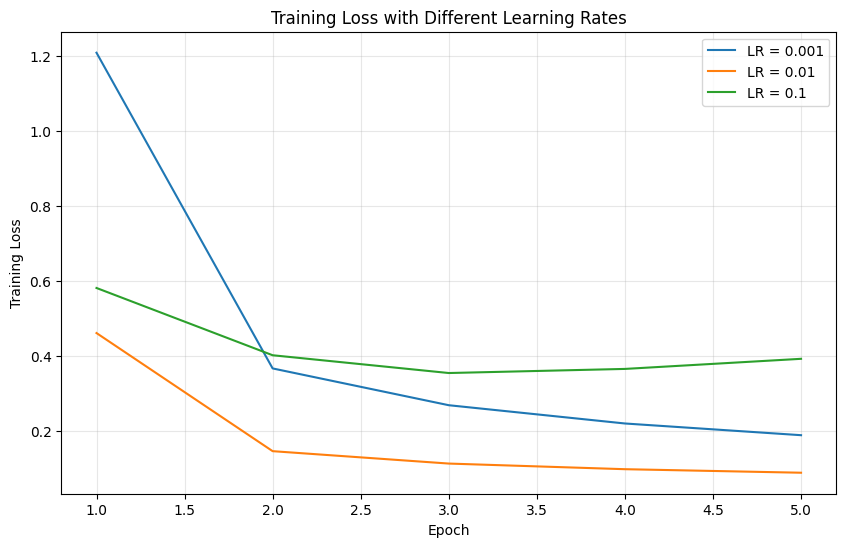

In [30]:
# Plotting the loss histories for different learning rates
plt.figure(figsize=(10, 6))
epochs_plot = range(1, 5 + 1)

for lr, losses in all_loss_histories.items():
    plt.plot(epochs_plot, losses, label=f'LR = {lr}')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss with Different Learning Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Quan sát:

*   **LR = 0.001 (quá thấp):** Loss giảm rất chậm, cho thấy mô hình đang học từng bước rất nhỏ và có thể cần nhiều epoch hơn để đạt được hiệu suất tốt. Điều này dẫn đến quá trình huấn luyện kéo dài.
*   **LR = 0.01 (tối ưu):** Loss giảm nhanh và ổn định, đạt được mức thấp nhất trong số các learning rate được thử nghiệm. Đây là learning rate hiệu quả nhất trong trường hợp này.
*   **LR = 0.1 (quá cao):** Loss dao động mạnh và có thể không hội tụ, hoặc thậm chí tăng lên. Learning rate quá cao khiến optimizer "nhảy vọt" qua các điểm cực tiểu cục bộ và khó tìm được điểm tối ưu.

### Giải thích:

Learning rate (`lr`) quyết định kích thước bước mà thuật toán tối ưu hóa (ở đây là SGD) thực hiện để cập nhật trọng số của mô hình trong quá trình học. Một cách hình dung, nó giống như tốc độ đi bộ của bạn trong một thung lũng để tìm điểm thấp nhất:

*   **`lr` quá thấp:** Bạn đi những bước rất nhỏ. Mặc dù bạn có thể đến được điểm thấp nhất, nhưng sẽ mất rất nhiều thời gian.
*   **`lr` tối ưu:** Bạn đi những bước vừa phải, đủ nhanh để đến đích mà không bị lạc đường.
*   **`lr` quá cao:** Bạn đi những bước quá lớn, có thể bạn sẽ "nhảy" qua điểm thấp nhất và không bao giờ ổn định ở đó, hoặc thậm chí "rơi" ra khỏi thung lũng (loss bùng nổ).

Do đó, việc chọn `lr` phù hợp là rất quan trọng để đảm bảo mô hình học hiệu quả và hội tụ tốt.